# DiffusionNet Autoencoder: Shape Clustering

This notebook loads the latent embeddings from the trained DiffusionNet autoencoder
and reproduces the tSNE/clustering analysis from `multi_shape_clustering.ipynb`
for direct comparison with the spectral (bag-of-features HKS) baseline.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import json
import os

In [2]:
# Configuration
data_path = '../Data/20260211'
output_dir = 'outputs'

with open(f'{data_path}/config.json', 'r') as f:
    cfg = json.load(f)
times_dic = cfg['times_dic']

In [3]:
# Load DiffusionNet latent embeddings
res = np.load(os.path.join(output_dir, 'latent_embeddings.npz'), allow_pickle=True)
latents = res['latents']
ids = res['ids']
timepoints = res['timepoints']
areas = res['areas']

# Extract time strings for colouring
times = np.array([tp[3:] for tp in timepoints])

print(f'Latent shape: {latents.shape}')
print(f'Number of organoids: {len(ids)}')

Latent shape: (20, 32)
Number of organoids: 20


In [ ]:
# Optionally load the spectral baseline for comparison
try:
    res_baseline = np.load(f'{data_path}/multi_shape_bof_results_raw_value.npz', allow_pickle=True)
    baseline_ids = res_baseline['filtered_ids']
    baseline_spectrums = res_baseline['filtered_spectrums']
    baseline_times = res_baseline['filtered_time']
    baseline_areas = res_baseline['filtered_areas']
    has_baseline = True
    print(f'Baseline loaded: {len(baseline_ids)} organoids')
except FileNotFoundError:
    has_baseline = False
    print('No baseline found (multi_shape_bof_results_raw_value.npz)')

## tSNE of DiffusionNet Latent Space

In [5]:
# Standardize latents before tSNE
scaler = StandardScaler()
latents_scaled = scaler.fit_transform(latents)

tsne = TSNE(n_components=2, perplexity=10, random_state=42)
tsne_coords = tsne.fit_transform(latents_scaled)
print('tSNE done.')

tSNE done.


In [6]:
# KMeans clustering
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_id = kmeans.fit_predict(latents_scaled)

# Find cluster centers in tSNE space
nn = NearestNeighbors(n_neighbors=5).fit(latents_scaled)
distances, indices = nn.kneighbors(kmeans.cluster_centers_)
weights = 1 / (distances + 1e-8)
weights /= weights.sum(axis=1, keepdims=True)
cluster_pcs = np.sum(weights[:, :, None] * tsne_coords[indices], axis=1)

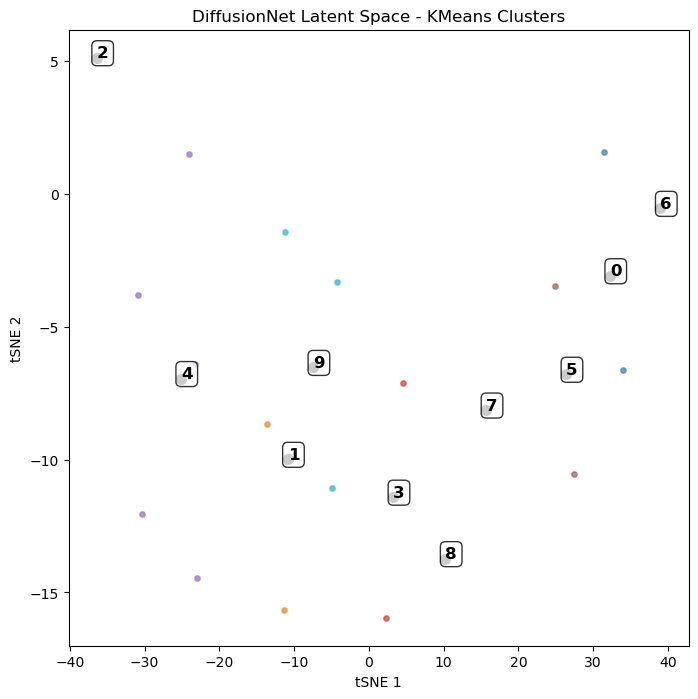

In [7]:
# Plot: clusters
plt.figure(figsize=(8, 8))
plt.plot(tsne_coords[:, 0], tsne_coords[:, 1], 'o', alpha=0.3, c='grey', markersize=3)

for cid in range(n_clusters):
    mask = cluster_id == cid
    plt.plot(tsne_coords[mask, 0], tsne_coords[mask, 1], 'o', alpha=0.5, markersize=4)

plt.plot(cluster_pcs[:, 0], cluster_pcs[:, 1], 'o', markersize=7, color='black')
for i in range(len(cluster_pcs)):
    plt.text(cluster_pcs[i, 0], cluster_pcs[i, 1],
             str(i), fontsize=12, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.8))

plt.xlabel('tSNE 1')
plt.ylabel('tSNE 2')
plt.title('DiffusionNet Latent Space - KMeans Clusters')
plt.show()

In [ ]:
# Plot: coloured by time
cmap = plt.get_cmap('Blues')
colors = cmap(np.linspace(0.2, 1.0, 256))
custom_cmap = ListedColormap(colors)

times_array = np.array([times_dic.get(t, 0) for t in times])

plt.figure(figsize=(8, 8))
sc = plt.scatter(tsne_coords[:, 0], tsne_coords[:, 1],
                 c=times_array, s=40, alpha=0.6, cmap=custom_cmap)
plt.colorbar(sc, label='Timepoint (days)')
plt.title('DiffusionNet Latent Space - Time')
plt.show()

plt.figure(figsize=(8, 8))
sc = plt.scatter(tsne_coords[:, 0], tsne_coords[:, 1],
                 c=areas, s=40, alpha=0.6, cmap=custom_cmap)
plt.colorbar(sc, label='Area')
plt.title('DiffusionNet Latent Space - Area')
plt.show()

In [ ]:
# Plot: per-timepoint panels
unique_times = np.unique(times)
cmap_time = plt.cm.viridis
colors_time = [cmap_time(i / max(1, len(unique_times) - 1)) for i in range(len(unique_times))]

fig, axes = plt.subplots(1, len(unique_times), figsize=(3 * len(unique_times), 4))
if len(unique_times) == 1:
    axes = [axes]

for i, t in enumerate(unique_times):
    ax = axes[i]
    ax.scatter(tsne_coords[:, 0], tsne_coords[:, 1], c='lightgray', alpha=0.5, s=10)
    mask = times == t
    ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
               c=[colors_time[i]], alpha=0.8, s=20)
    ax.set_title(f'Day {t} (n={mask.sum()})')
    ax.set_xlabel('tSNE 1')

axes[0].set_ylabel('tSNE 2')
plt.suptitle('DiffusionNet: Time progression', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Save results
df = pd.DataFrame({
    'label_uid': ids,
    'tsne1': tsne_coords[:, 0],
    'tsne2': tsne_coords[:, 1],
    'cluster': cluster_id,
})
df.to_csv(os.path.join(output_dir, 'diffusionnet_tsne_results.csv'), index=False)
print(df.head())

## Comparison with Spectral Baseline

If the spectral baseline results exist, show both embeddings side by side.

In [ ]:
if has_baseline:
    # Match IDs between the two methods
    dn_id_set = set(ids)
    bl_id_set = set(baseline_ids)
    common_ids = sorted(dn_id_set & bl_id_set)
    print(f'Common organoids: {len(common_ids)} / DN: {len(ids)} / Baseline: {len(baseline_ids)}')

    # Load baseline tSNE if it exists
    try:
        bl_tsne = pd.read_csv(f'{data_path}/tsne_results_raw_value.csv')
        print('Baseline tSNE loaded from CSV')
    except FileNotFoundError:
        print('No baseline tSNE CSV found')
        bl_tsne = None

    if bl_tsne is not None:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

        ax1.scatter(tsne_coords[:, 0], tsne_coords[:, 1],
                    c=times_array, s=20, alpha=0.6, cmap=custom_cmap)
        ax1.set_title('DiffusionNet Latent Space')
        ax1.set_xlabel('tSNE 1')
        ax1.set_ylabel('tSNE 2')

        bl_times_array = np.array([times_dic.get(t, 0) for t in bl_tsne['label_uid'].apply(
            lambda x: x.split('_')[0][3:])])
        sc = ax2.scatter(bl_tsne['tsne1'], bl_tsne['tsne2'],
                         c=bl_times_array, s=20, alpha=0.6, cmap=custom_cmap)
        ax2.set_title('Spectral Baseline (BoF HKS)')
        ax2.set_xlabel('tSNE 1')
        ax2.set_ylabel('tSNE 2')

        plt.colorbar(sc, ax=[ax1, ax2], label='Timepoint (days)')
        plt.suptitle('DiffusionNet vs Spectral Baseline', fontsize=14)
        plt.tight_layout()
        plt.show()
else:
    print('No baseline data to compare.')